# OpenMC transport model for the frm2 geometry using natural uranium

Modularize so concentric_modeling.ipynb reuses python files
Optimization.py should follow a similar workflow, searching for best k_eff (closest to 1.005) then presenting a list of best candidates (because size matters and I prefer smaller cores)


 ## Models

In [129]:
import importlib
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openmc

import fuel_element
import involutes
import reactor_geometry
from ploting import resolve_openmc_exec

importlib.reload(involutes)
importlib.reload(fuel_element)
importlib.reload(reactor_geometry)

from fuel_element import quick_layout_plot
from involutes import InvoluteElementParameters, build_parameter_report, spiral_summary, validate_parameters
from reactor_geometry import ReactorTankParameters, build_reactor_model, validate_reactor_tanks

FUEL_ELEMENT_PARAMETERS = InvoluteElementParameters(
    plate_count=12,
    plate_thickness_cm=1.0, #0.8,
    coolant_gap_cm=12.0,
    inner_radius_cm=25.0,
    outer_radius_cm=50.0,
    control_rod_radius_cm=4.0,
    h_active_cm=300.0,
    lower_plenum_cm=50.0,
    upper_plenum_cm=50.0,
    segments_per_plate=24,
    base_radius_cm=None,
    fuel_density_g_per_cm3=12.2,
    fuel_enrichment_wt_pct=0.7198,
 )
# k = 1.07 with: 12 plates, plate_thickness_cm=1.0, coolant_gap_cm=12.0, inner_radius_cm=25.0, outer_radius_cm=50.0, h_active_cm=300.0

REACTOR_TANK_PARAMETERS = ReactorTankParameters(
    d2o_tank_radius_cm=300, #175.0, #300
    h2o_tank_radius_cm=500.0,
    h_d2o_tank_cm=600, #500.0, #600
    h_h2o_tank_cm=1000.0,
 )

validate_parameters(FUEL_ELEMENT_PARAMETERS)
validate_reactor_tanks(FUEL_ELEMENT_PARAMETERS, REACTOR_TANK_PARAMETERS)

GEOMETRY = build_parameter_report(FUEL_ELEMENT_PARAMETERS)
GEOMETRY.update(REACTOR_TANK_PARAMETERS.to_geometry_dict())

GLOBAL_MESH_SHAPE = (160, 160)
FUEL_MESH_SHAPE = (220, 220)
DEFAULT_OPENMC_THREADS = os.cpu_count() or 1
OPENMC_THREADS = int(os.environ.get("OPENMC_THREADS", DEFAULT_OPENMC_THREADS))
OPENMC_EXEC = resolve_openmc_exec()

BUILD_DIR = Path("build") / "notebook"
PREVIEW_DIR = BUILD_DIR / "preview"
RUN_DIR = BUILD_DIR / "reactor_run"
for build_path in (BUILD_DIR, PREVIEW_DIR, RUN_DIR):
    build_path.mkdir(parents=True, exist_ok=True)

GEOMETRY_REPORT = {
    "fuel_element": build_parameter_report(FUEL_ELEMENT_PARAMETERS),
    "reactor_tanks": REACTOR_TANK_PARAMETERS.to_geometry_dict(),
    "openmc_threads": OPENMC_THREADS,
    "openmc_exec": OPENMC_EXEC,
}
GEOMETRY_REPORT

{'fuel_element': {'plate_count': 12,
  'plate_thickness_cm': 1.0,
  'coolant_gap_cm': 12.0,
  'inner_radius_cm': 25.0,
  'outer_radius_cm': 50.0,
  'control_rod_radius_cm': 4.0,
  'h_active_cm': 300.0,
  'lower_plenum_cm': 50.0,
  'upper_plenum_cm': 50.0,
  'segments_per_plate': 24,
  'base_radius_cm': 24.82817112233567,
  'fuel_density_g_per_cm3': 12.2,
  'fuel_enrichment_wt_pct': 0.7198,
  'h_total_cm': 400.0,
  'theta_inner': np.float64(0.11785304835283968),
  'theta_outer': np.float64(1.7480152642423428),
  'single_plate_length_cm': np.float64(57.21512534024451),
  'uranium_area_fraction': np.float64(0.1165576962242851),
  'uranium_volume_cm3': np.float64(205974.45122488023),
  'uranium_mass_kg': np.float64(2512.8883049435385)},
 'reactor_tanks': {'d2o_tank_radius_cm': 300,
  'h2o_tank_radius_cm': 500.0,
  'h_d2o_tank_cm': 600,
  'h_h2o_tank_cm': 1000.0,
  'h_total_cm': 1000.0},
 'openmc_threads': 19,
 'openmc_exec': '/home/pablo/miniconda3/envs/openmc/bin/openmc'}

In [130]:
from matplotlib.colors import LogNorm

def estimate_particles_per_mesh_bin(particles, batches, inactive, mesh_shape):
    active_batches = max(0, batches - inactive)
    mesh_bins = mesh_shape[0] * mesh_shape[1]
    if mesh_bins <= 0 or active_batches <= 0:
        return 0.0
    return particles * active_batches / mesh_bins


def build_model(
    rod_insertion=0.0,
    particles=12000,
    batches=100,
    inactive=20,
    global_mesh_shape=None,
    fuel_mesh_shape=None,
):
    rod_insertion = float(np.clip(rod_insertion, 0.0, 1.0))
    model, metadata = build_reactor_model(
        FUEL_ELEMENT_PARAMETERS,
        REACTOR_TANK_PARAMETERS,
        rod_insertion=rod_insertion,
    )

    total_half = 0.5 * REACTOR_TANK_PARAMETERS.h_h2o_tank_cm
    active_half = 0.5 * FUEL_ELEMENT_PARAMETERS.h_active_cm

    source = openmc.IndependentSource(
        space=openmc.stats.CylindricalIndependent(
            r=openmc.stats.PowerLaw(
                FUEL_ELEMENT_PARAMETERS.inner_radius_cm,
                FUEL_ELEMENT_PARAMETERS.outer_radius_cm,
                1.0,
            ),
            phi=openmc.stats.Uniform(0.0, 2.0 * np.pi),
            z=openmc.stats.Uniform(-active_half, active_half),
        ),
        constraints={"fissionable": True},
    )

    settings = openmc.Settings()
    settings.run_mode = "eigenvalue"
    settings.particles = particles
    settings.batches = batches
    settings.inactive = inactive
    settings.source = source
    settings.source_rejection_fraction = 0.01
    settings.temperature = {"method": "interpolation"}
    model.settings = settings

    tallies = []

    if global_mesh_shape is not None:
        global_mesh = openmc.RegularMesh()
        global_mesh.dimension = (global_mesh_shape[0], 1, global_mesh_shape[1])
        global_mesh.lower_left = (-REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm, -1.0, -total_half)
        global_mesh.upper_right = (REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm, 1.0, total_half)

        global_tally = openmc.Tally(name="global-mesh")
        global_tally.filters = [openmc.MeshFilter(global_mesh)]
        global_tally.scores = ["flux", "fission", "nu-fission"]
        tallies.append(global_tally)
        metadata["global_mesh_shape"] = tuple(global_mesh.dimension)
        metadata["global_mesh_histories_per_bin"] = estimate_particles_per_mesh_bin(particles,batches,inactive,global_mesh_shape)

    if fuel_mesh_shape is not None:
        fuel_mesh = openmc.RegularMesh()
        fuel_mesh.dimension = (fuel_mesh_shape[0], 1, fuel_mesh_shape[1])
        fuel_mesh.lower_left = (
            -FUEL_ELEMENT_PARAMETERS.outer_radius_cm,
            -1.0,
            -0.5 * FUEL_ELEMENT_PARAMETERS.h_active_cm,
        )
        fuel_mesh.upper_right = (
            FUEL_ELEMENT_PARAMETERS.outer_radius_cm,
            1.0,
            0.5 * FUEL_ELEMENT_PARAMETERS.h_active_cm,
        )

        fuel_tally = openmc.Tally(name="fuel-mesh")
        fuel_tally.filters = [openmc.MeshFilter(fuel_mesh)]
        fuel_tally.scores = ["flux", "fission", "nu-fission"]
        tallies.append(fuel_tally)
        metadata["fuel_mesh_shape"] = tuple(fuel_mesh.dimension)
        metadata["fuel_mesh_histories_per_bin"] = estimate_particles_per_mesh_bin(particles,batches,inactive,fuel_mesh_shape)

    if tallies:
        model.tallies = openmc.Tallies(tallies)

    metadata["tally_names"] = [tally.name for tally in tallies]
    metadata["particles"] = particles
    metadata["batches"] = batches
    metadata["inactive"] = inactive
    return model, metadata

{'plate_count': 12, 'plate_thickness_cm': 1.0, 'coolant_gap_cm': 12.0, 'inner_radius_cm': 25.0, 'outer_radius_cm': 50.0, 'control_rod_radius_cm': 4.0, 'h_active_cm': 300.0, 'lower_plenum_cm': 50.0, 'upper_plenum_cm': 50.0, 'segments_per_plate': 24, 'base_radius_cm': 24.82817112233567, 'fuel_density_g_per_cm3': 12.2, 'fuel_enrichment_wt_pct': 0.7198, 'h_total_cm': 400.0, 'theta_inner': np.float64(0.11785304835283968), 'theta_outer': np.float64(1.7480152642423428), 'single_plate_length_cm': np.float64(57.21512534024451), 'uranium_area_fraction': np.float64(0.1165576962242851), 'uranium_volume_cm3': np.float64(205974.45122488023), 'uranium_mass_kg': np.float64(2512.8883049435385)}


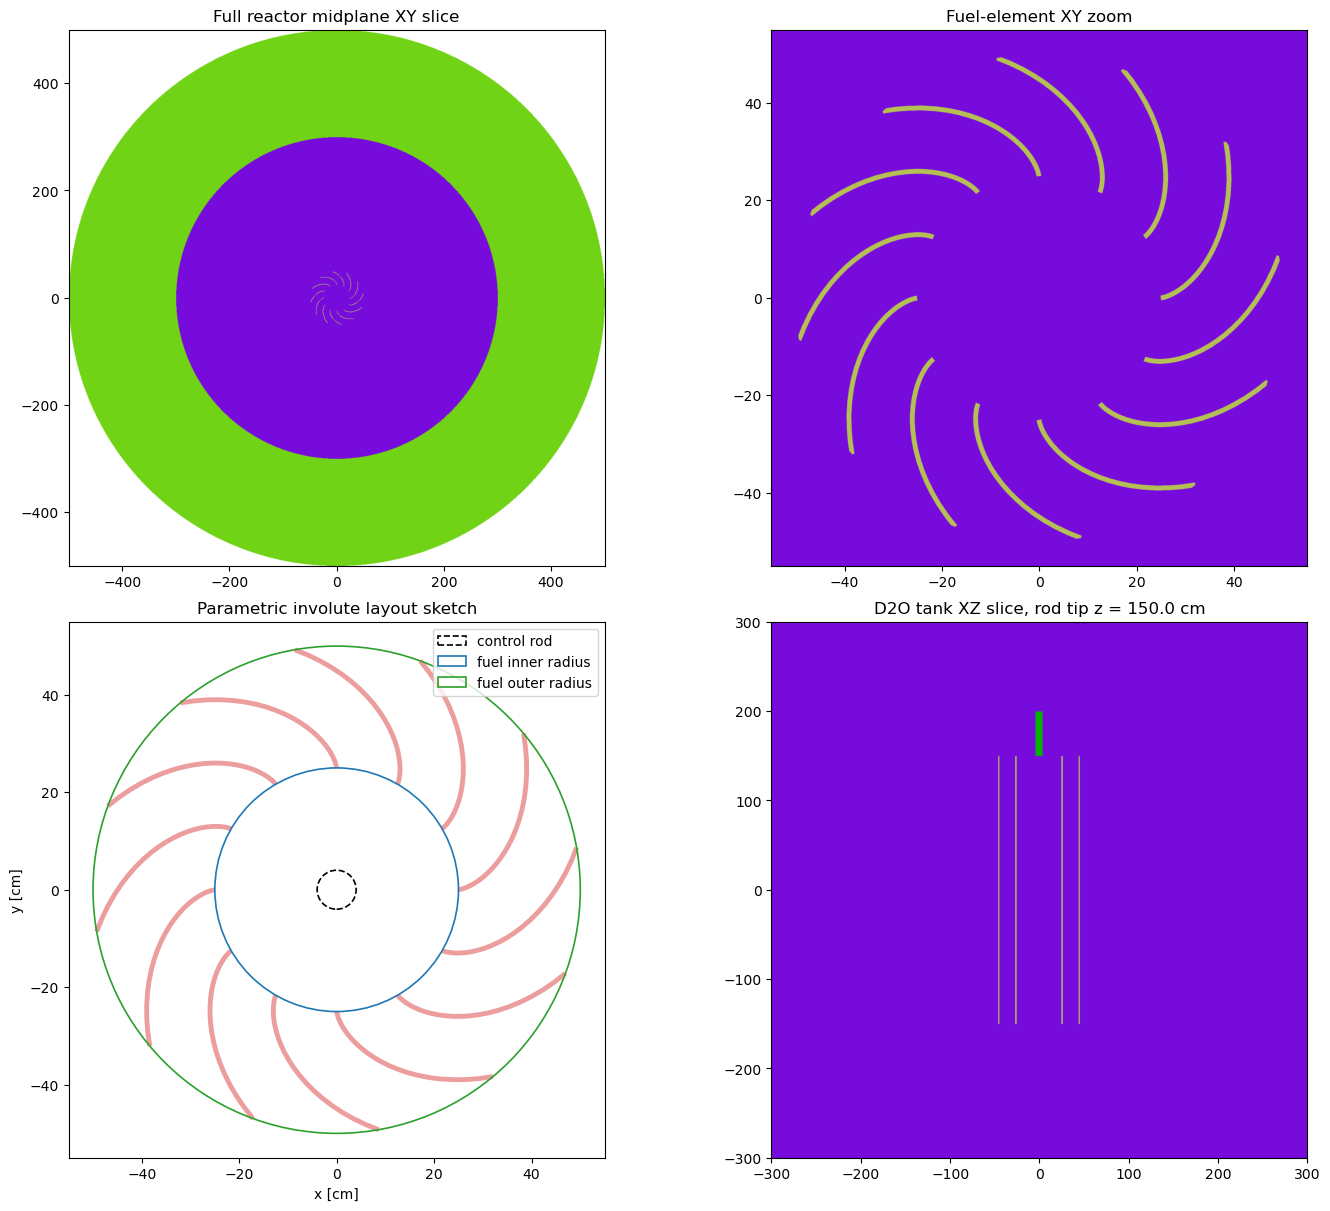

In [131]:
preview_model, preview_metadata = build_model(
    rod_insertion=0.0,
    particles=2000,
    batches=1,
    inactive=0,
    global_mesh_shape=None,
    fuel_mesh_shape=None,
)

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)

preview_model.geometry.root_universe.plot(
    origin=(0.0, 0.0, 0.0),
    width=(
        2.0 * REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm,
        2.0 * REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm,
    ),
    basis="xy",
    color_by="material",
    pixels=(1200, 1200),
    axes=axes[0, 0],
)
axes[0, 0].set_title("Full reactor midplane XY slice")

preview_model.geometry.root_universe.plot(
    origin=(0.0, 0.0, 0.0),
    width=(
        2.2 * FUEL_ELEMENT_PARAMETERS.outer_radius_cm,
        2.2 * FUEL_ELEMENT_PARAMETERS.outer_radius_cm,
    ),
    basis="xy",
    color_by="material",
    pixels=(2200, 2200),
    axes=axes[0, 1],
)
axes[0, 1].set_title("Fuel-element XY zoom")

quick_layout_plot(FUEL_ELEMENT_PARAMETERS, ax=axes[1, 0])
axes[1, 0].set_title("Parametric involute layout sketch")

preview_model.geometry.root_universe.plot(
    origin=(0.0, 0.0, 0.0),
    width=(
        2.0 * REACTOR_TANK_PARAMETERS.d2o_tank_radius_cm,
        REACTOR_TANK_PARAMETERS.h_d2o_tank_cm,
    ),
    basis="xz",
    color_by="material",
    pixels=(1800, 1600),
    axes=axes[1, 1],
)
axes[1, 1].set_title(f"D2O tank XZ slice, rod tip z = {preview_metadata['fuel_element']['rod_tip_z_cm']:.1f} cm")

print(build_parameter_report(FUEL_ELEMENT_PARAMETERS))
plt.show()

In [134]:
cross_sections = openmc.config.get("cross_sections")

if cross_sections:
    reference_insertion = 0.0
    reference_model, reference_metadata = build_model(
        rod_insertion=reference_insertion,
        particles=12000,
        batches=30,
        inactive=10,
        global_mesh_shape=None,
        fuel_mesh_shape=None,
    )
    statepoint_path = reference_model.run(
        cwd=RUN_DIR,
        threads=OPENMC_THREADS,
        openmc_exec=OPENMC_EXEC,
        export_model_xml=True,
    )
    print(f"OpenMC run finished: {statepoint_path}")
    print(f"model.xml written to {RUN_DIR / 'model.xml'}")
    if reference_metadata["tally_names"]:
        print(f"Tallies recorded: {reference_metadata['tally_names']}")
    else:
        print("No mesh tallies were attached to this run, so this is a faster k_eff-only calculation.")
else:
    statepoint_path = None
    reference_metadata = None
    print(
        "Set openmc.config['cross_sections'] or OPENMC_CROSS_SECTIONS before running eigenvalue calculations."
    )

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

KeyboardInterrupt: 

# Plotting Tallies

Too much code -> streamline and migrate stuff to ploting.py if necessary

In [133]:
# try:
#     with openmc.StatePoint(statepoint_path) as statepoint:
#         keff = statepoint.keff
#         rho_pcm = (keff.n - 1.0) / keff.n * 1.0e5
#         print(f"k_eff = {keff.n:.6f} +/- {keff.s:.6f}")
#         print(f"reactivity = {rho_pcm:.1f} pcm")

#         tally_names = reference_metadata.get("tally_names", []) if reference_metadata is not None else []
#         if not tally_names:
#             print("This run was executed without mesh tallies for speed. Rebuild with global_mesh_shape or fuel_mesh_shape to plot maps.")
#         else:
#             tally_name = "global-mesh" if "global-mesh" in tally_names else tally_names[0]
#             mesh_tally = statepoint.get_tally(name=tally_name)
#             flux_tally = mesh_tally.get_slice(scores=["flux"])
#             fission_tally = mesh_tally.get_slice(scores=["fission"])

#             flux = flux_tally.get_reshaped_data(value="mean").reshape(tuple(mesh_tally.filters[0].mesh.dimension)).squeeze()
#             fission = fission_tally.get_reshaped_data(value="mean").reshape(tuple(mesh_tally.filters[0].mesh.dimension)).squeeze()
#             flux_std = flux_tally.get_reshaped_data(value="std_dev").reshape(tuple(mesh_tally.filters[0].mesh.dimension)).squeeze()
#             fission_std = fission_tally.get_reshaped_data(value="std_dev").reshape(tuple(mesh_tally.filters[0].mesh.dimension)).squeeze()

#             flux_masked = np.ma.masked_less_equal(flux, 0.0)
#             fission_masked = np.ma.masked_less_equal(fission, 0.0)
#             flux_rel_err = np.ma.masked_where((flux <= 0.0) | ~np.isfinite(flux_std), flux_std / flux)
#             fission_rel_err = np.ma.masked_where((fission <= 0.0) | ~np.isfinite(fission_std), fission_std / fission)

#             positive_flux = np.asarray(flux[flux > 0.0])
#             positive_fission = np.asarray(fission[fission > 0.0])

#             if tally_name == "fuel-mesh":
#                 extent = [
#                     -FUEL_ELEMENT_PARAMETERS.outer_radius_cm,
#                     FUEL_ELEMENT_PARAMETERS.outer_radius_cm,
#                     -0.5 * FUEL_ELEMENT_PARAMETERS.h_active_cm,
#                     0.5 * FUEL_ELEMENT_PARAMETERS.h_active_cm,
#                 ]
#                 histories_per_bin = reference_metadata.get("fuel_mesh_histories_per_bin")
#             else:
#                 extent = [
#                     -REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm,
#                     REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm,
#                     -0.5 * REACTOR_TANK_PARAMETERS.h_h2o_tank_cm,
#                     0.5 * REACTOR_TANK_PARAMETERS.h_h2o_tank_cm,
#                 ]
#                 histories_per_bin = reference_metadata.get("global_mesh_histories_per_bin")

#             print(f"{tally_name} histories per bin: {histories_per_bin:.3f}")
#             print(f"flux nonzero fraction: {(flux > 0.0).mean():.3f}")
#             print(f"fission nonzero fraction: {(fission > 0.0).mean():.3f}")
#             if histories_per_bin is not None and histories_per_bin < 10.0:
#                 print("This mesh is strongly under-sampled. Increase active batches/particles or reduce the mesh size for a readable map.")

#             fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

#             flux_norm = LogNorm(
#                 vmin=max(np.percentile(positive_flux, 5), positive_flux.min()),
#                 vmax=positive_flux.max(),
#             )
#             fission_norm = LogNorm(
#                 vmin=max(np.percentile(positive_fission, 5), positive_fission.min()),
#                 vmax=positive_fission.max(),
#             )

#             flux_image = axes[0, 0].imshow(
#                 flux_masked.T,
#                 origin="lower",
#                 aspect="auto",
#                 extent=extent,
#                 norm=flux_norm,
#                 cmap="viridis",
#             )
#             axes[0, 0].set_xlabel("x [cm]")
#             axes[0, 0].set_ylabel("z [cm]")
#             axes[0, 0].set_title(f"Flux score ({tally_name}, log scale)")
#             plt.colorbar(flux_image, ax=axes[0, 0], label="flux")

#             fission_image = axes[0, 1].imshow(
#                 fission_masked.T,
#                 origin="lower",
#                 aspect="auto",
#                 extent=extent,
#                 norm=fission_norm,
#                 cmap="magma",
#             )
#             axes[0, 1].set_xlabel("x [cm]")
#             axes[0, 1].set_ylabel("z [cm]")
#             axes[0, 1].set_title(f"Fission score ({tally_name}, log scale)")
#             plt.colorbar(fission_image, ax=axes[0, 1], label="fission")

#             flux_rel_err_finite = np.asarray(flux_rel_err.filled(np.nan))
#             flux_rel_err_finite = flux_rel_err_finite[np.isfinite(flux_rel_err_finite)]
#             fission_rel_err_finite = np.asarray(fission_rel_err.filled(np.nan))
#             fission_rel_err_finite = fission_rel_err_finite[np.isfinite(fission_rel_err_finite)]

#             if flux_rel_err_finite.size == 0 or fission_rel_err_finite.size == 0:
#                 axes[1, 0].axis("off")
#                 axes[1, 1].axis("off")
#                 axes[1, 0].text(
#                     0.5,
#                     0.5,
#                     "Relative error is unavailable with only one active batch.",
#                     ha="center",
#                     va="center",
#                     wrap=True,
#                 )
#                 axes[1, 1].text(
#                     0.5,
#                     0.5,
#                     "Run more active batches to estimate tally uncertainty.",
#                     ha="center",
#                     va="center",
#                     wrap=True,
#                 )
#             else:
#                 flux_err_image = axes[1, 0].imshow(
#                     flux_rel_err.T,
#                     origin="lower",
#                     aspect="auto",
#                     extent=extent,
#                     vmin=0.0,
#                     vmax=min(2.0, float(np.percentile(flux_rel_err_finite, 95))),
#                     cmap="cividis",
#                 )
#                 axes[1, 0].set_xlabel("x [cm]")
#                 axes[1, 0].set_ylabel("z [cm]")
#                 axes[1, 0].set_title("Flux relative error")
#                 plt.colorbar(flux_err_image, ax=axes[1, 0], label="std. dev. / mean")

#                 fission_err_image = axes[1, 1].imshow(
#                     fission_rel_err.T,
#                     origin="lower",
#                     aspect="auto",
#                     extent=extent,
#                     vmin=0.0,
#                     vmax=min(2.0, float(np.percentile(fission_rel_err_finite, 95))),
#                     cmap="cividis",
#                 )
#                 axes[1, 1].set_xlabel("x [cm]")
#                 axes[1, 1].set_ylabel("z [cm]")
#                 axes[1, 1].set_title("Fission relative error")
#                 plt.colorbar(fission_err_image, ax=axes[1, 1], label="std. dev. / mean")
#             plt.show()
# except (FileNotFoundError, NameError, TypeError):
#     print("Run the previous cell after configuring OpenMC nuclear data to get k_eff and optional flux/fission maps.")